# Inventory Service-Level Modeling Across Multiple Stores

## Business use case

Retailers need to decide how much inventory to position across a network when demand is uncertain. Holding too much stock ties up cash; holding too little creates service failures. A probabilistic model converts that trade-off into explicit service-level targets.

## Objective

The notebook models store demand as independent Normal random variables with mean 800 units and standard deviation 250 units. It calculates the probability that aggregate demand stays below a chosen supply level and uses Normal quantiles to estimate inventory required for target service probabilities.

## Result in context

For two stores with 2,000 units of combined supply, the stored service probability is **87.11%** and the 95th-percentile demand is about **2,182 units**. For 12 stores, the 95th-percentile aggregate demand is about **11,024 units**.


## Step 1 — Set up the probability model

NumPy, SciPy, Matplotlib, and Python's math library are used to calculate and visualize Normal demand distributions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import math

## Step 2 — Define the base demand assumptions

Each store is modeled with expected demand of 800 units and standard deviation of 250 units. The first scenario uses two independent stores and assumes 1,000 units of inventory per store.


In [2]:
#Expected Total Demand
expTotDemand = 800

#Number of Stores
numStores = 2

#Independant Standard deviation
iStd = 250

#Number of iterations
n=1000

## Step 3 — Evaluate the two-store service level

Aggregate demand has mean equal to the sum of store means and standard deviation that grows with the square root of the number of independent stores. The CDF gives the probability that demand is covered by the available supply, while the inverse CDF gives required inventory for a target probability.


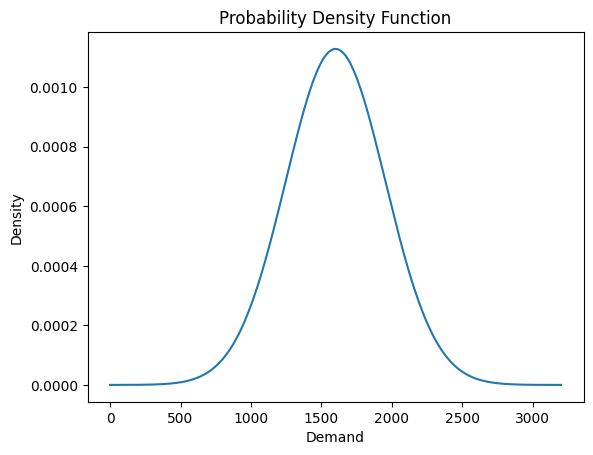

In [3]:
#Guaranteed supply if all stores get 1000 units
guaranteedSupply = 1000 * numStores

# Calculate the mean
mean = expTotDemand * numStores

#Calculate standard deviation
std = math.sqrt(numStores) * iStd

#configure the line space
x = np.linspace(0, 1600 * numStores, n)

pdf_result = stats.norm.pdf(x,loc=mean,scale=std)

#Lable and plot the PDF against the pre-defined line space
plt.plot(x,pdf_result)
plt.xlabel('Demand')
plt.ylabel('Density')
plt.title("Probability Density Function")
plt.show()

In [4]:
cdf = stats.norm.cdf(guaranteedSupply,mean,std)
cdf

np.float64(0.8710504823538303)

In [5]:
ppf = stats.norm.ppf(0.95,mean,std)
ppf

np.float64(2181.543576838337)

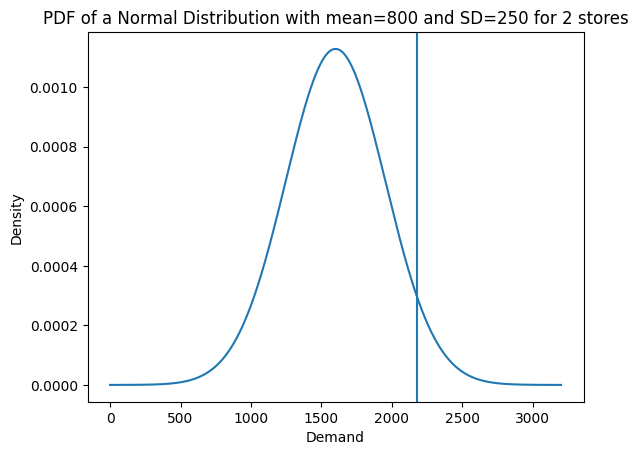

In [6]:
#Plot the PPF as a line
plt.axvline(ppf)
plt.plot(x,pdf_result)

plt.xlabel('Demand')
plt.ylabel('Density')
plt.title("PDF of a Normal Distribution with mean=800 and SD=250 for 2 stores")
plt.show()

## Step 4 — Scale the model to a 12-store network

The same assumptions are extended to 12 independent stores. This illustrates the pooling effect: average demand scales linearly with store count, while uncertainty grows more slowly under independence.


In [7]:
#Number of Stores
numStores = 12

In [8]:
#Guaranteed supply if all stores get 1000 units
guaranteedSupply = 1000 * numStores

#Calculate the mean
mean = expTotDemand * numStores

#Calculate standard deviation
std = math.sqrt(numStores) * iStd


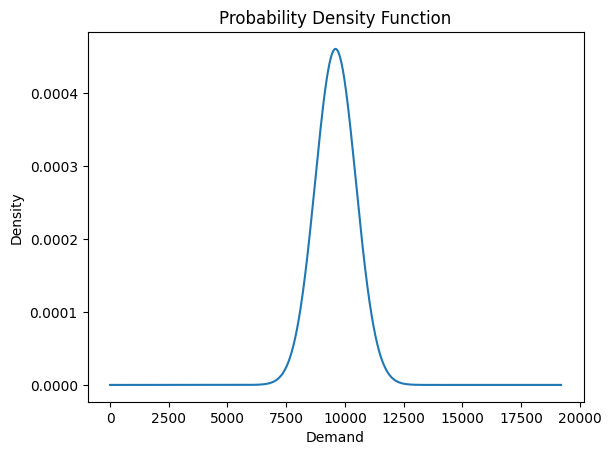

In [9]:
#configure the line space
x = np.linspace(0, 1600 * numStores, n)

pdf_result = stats.norm.pdf(x,loc=mean,scale=std)

#Lable and plot the PDF against the pre-defined line space
plt.plot(x,pdf_result)
plt.xlabel('Demand')
plt.ylabel('Density')
plt.title("Probability Density Function")
plt.show()

## Step 5 — Compare alternative service targets

The stored calculations evaluate several supply/service points. With 12 stores, 12,000 units corresponds to about **99.72%** probability of covering aggregate demand, while 9,500 units covers only about **45.40%**. The 85%, 95%, and 99% demand quantiles are approximately 10,498, 11,024, and 11,615 units.


In [10]:
cdf = stats.norm.cdf(guaranteedSupply,mean,std)
cdf

np.float64(0.9972081915968106)

In [11]:
cdf9500 = stats.norm.cdf(9500,12*800,250*math.sqrt(12))
ppfnow = 9500
ppfnow
cdf9500

np.float64(0.4540362776279876)

In [12]:
ppf95 = stats.norm.ppf(0.95,mean,std)
ppf95

np.float64(11024.485026446948)

In [13]:
ppf85 = stats.norm.ppf(0.85,mean,std)
ppf85

np.float64(10497.577644632034)

In [14]:
ppf99 = stats.norm.ppf(0.99,mean,std)
ppf99

np.float64(11614.67635695929)

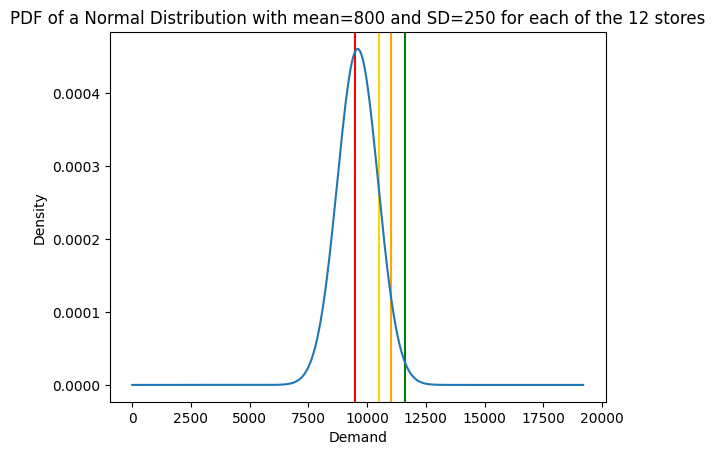

In [15]:
#Plot the PPF as a line
plt.axvline(ppf95,color='orange')
plt.axvline(ppf85,color='gold')
plt.axvline(ppf99,color='green')
plt.axvline(ppfnow,color='red')
plt.plot(x,pdf_result)

plt.xlabel('Demand')
plt.ylabel('Density')
plt.title("PDF of a Normal Distribution with mean=800 and SD=250 for each of the 12 stores")
plt.show()

## Step 6 — Visualize the supply-service trade-off

The CDF curve shows how service probability changes as aggregate supply increases. This is the most decision-friendly view because planners can read the inventory cost implied by a desired risk level.


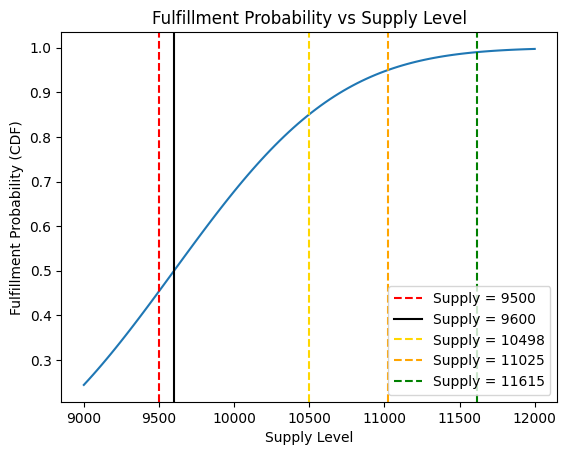

In [19]:

# Explore different supply levels
supply_levels = np.linspace(9000, 12000, 100)
cdf_values = stats.norm.cdf(supply_levels, loc=mean, scale=std)

# Plot the CDF curve
plt.plot(supply_levels, cdf_values)
plt.axvline(9500, color='red', linestyle='--', label=f'Supply = 9500')
plt.axvline(9600, color='black', linestyle='-', label=f'Supply = 9600')
plt.axvline(10497, color='gold', linestyle='--', label=f'Supply = 10498')
plt.axvline(11024, color='orange', linestyle='--', label=f'Supply = 11025')
plt.axvline(11614, color='green', linestyle='--', label=f'Supply = 11615')
plt.xlabel('Supply Level')
plt.ylabel('Fulfillment Probability (CDF)')
plt.title('Fulfillment Probability vs Supply Level')
plt.legend()
plt.show()


## Technical conclusions

The model demonstrates risk pooling clearly. For 12 independent stores, the standard deviation of aggregate demand grows with √12 rather than 12, so the safety stock required per store falls as the network is pooled.

The calculations rely on two strong assumptions: demand is Normal and store demands are independent. Positive correlation between stores—common during promotions, weather events, or holidays—would increase aggregate risk and make the current service estimates optimistic.

## Business conclusions

The model gives inventory planners a direct way to translate a service target into a network stock level. For the stated assumptions, a 95% aggregate service probability requires roughly **11,024 units** across 12 stores, versus the 9,600-unit mean demand.

## Limitations and next steps

I would estimate demand distributions and cross-store correlations from historical data, separate cycle stock from safety stock, and compare centralized versus store-level allocation policies before using this for operational planning.
